# Pointwise Judge Preference — Exploratory Analysis

Explores the head-to-head preferences derived from pointwise judge scores in
`output/judge_results_train_api.jsonl` (see `script/compute_pointwise_preference.py`).

For every (question, judge) pair, the two answerer models
(`swiss-ai/Apertus-70B-Instruct-2509` vs `meta-llama/Llama-3.3-70B-Instruct`) are compared
on their **overall score** (mean of accuracy/completeness/topic_coherence/citation_quality,
1-5 scale each). The gap between the two overall scores (0-4 range) determines:

- `tie` — gap == 0
- `weak` preference — 0 < gap < `STRONG_PREFERENCE_THRESHOLD` (1.5)
- `strong` preference — gap >= 1.5 (the judge "completely"/decisively prefers one answer)

Inputs:
- `output/pointwise_preference_comparisons.json` — one row per (question, judge)
- `output/pointwise_preference_consensus.json` — per-question majority vote across the 3 judges
- `output/pointwise_preference_summary.csv` — pre-aggregated stats by judge / judge x regulator / overall
- `output/judge_results_train_api.jsonl` — original records, used here to pull question/answer text for examples

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 4)})

BASE = Path("../output")
STRONG_PREFERENCE_THRESHOLD = 1.5

comparisons = json.load(open(BASE / "pointwise_preference_comparisons.json"))
consensus = json.load(open(BASE / "pointwise_preference_consensus.json"))

df = pd.DataFrame(comparisons)
cdf = pd.DataFrame(consensus)

ANSWERERS = sorted(set(df["answerer_1"]) | set(df["answerer_2"]))
JUDGES = sorted(df["judge_model"].unique())

print(f"Comparisons (question x judge): {len(df)}")
print(f"Questions (consensus rows)     : {len(cdf)}")
print(f"Answerer models                : {ANSWERERS}")
print(f"Judge models                    : {JUDGES}")
df.head()

Comparisons (question x judge): 6314
Questions (consensus rows)     : 2134
Answerer models                : ['meta-llama/Llama-3.3-70B-Instruct', 'swiss-ai/Apertus-70B-Instruct-2509']
Judge models                    : ['Qwen/Qwen3.5-27B', 'google/gemma-4-31B-it', 'zai-org/GLM-4.7-Flash']


,question_id,regulator,judge_model,answerer_1,answerer_2,overall_1,overall_2,diff,abs_diff,preferred,preference_strength
0,EBA_2015_1770,EBA,Qwen/Qwen3.5-27B,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,4.5,4.00,0.50,0.50,meta-llama/Llama-3.3-70B-Instruct,weak
1,EBA_2015_1770,EBA,google/gemma-4-31B-it,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,5.0,5.00,0.00,0.00,tie,tie
2,EBA_2015_1770,EBA,zai-org/GLM-4.7-Flash,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,5.0,5.00,0.00,0.00,tie,tie
3,EBA_2015_2051,EBA,Qwen/Qwen3.5-27B,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,3.5,1.75,1.75,1.75,meta-llama/Llama-3.3-70B-Instruct,strong
4,EBA_2015_2051,EBA,google/gemma-4-31B-it,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,3.5,2.00,1.50,1.50,meta-llama/Llama-3.3-70B-Instruct,strong


## 1 · Overview

In [2]:
print("=== Preferred-answer counts (pooled across all judges) ===")
print(df["preferred"].value_counts())
print()

print("=== Preference strength (pooled) ===")
print(df["preference_strength"].value_counts())
print()

summary = pd.read_csv(BASE / "pointwise_preference_summary.csv")
summary

=== Preferred-answer counts (pooled across all judges) ===
preferred
meta-llama/Llama-3.3-70B-Instruct     3623
swiss-ai/Apertus-70B-Instruct-2509    1732
tie                                    959
Name: count, dtype: int64

=== Preference strength (pooled) ===
preference_strength
weak      4652
tie        959
strong     703
Name: count, dtype: int64



,judge_model,mean_abs_diff,n,regulator,strong_preference,strong_preference_rate,ties,weak_preference,wins_meta-llama/Llama-3.3-70B-Instruct,wins_swiss-ai/Apertus-70B-Instruct-2509
0,Qwen/Qwen3.5-27B,0.5328,2134,NaN,151,0.0708,382,1601,1167,585
1,google/gemma-4-31B-it,0.5820,2134,NaN,188,0.0881,349,1597,1259,526
2,zai-org/GLM-4.7-Flash,0.7732,2046,NaN,364,0.1779,228,1454,1197,621
3,Qwen/Qwen3.5-27B,0.5139,1868,EBA,123,0.0658,342,1403,1003,523
4,Qwen/Qwen3.5-27B,0.6654,266,ESMA,28,0.1053,40,198,164,62
5,google/gemma-4-31B-it,0.5739,1868,EBA,159,0.0851,316,1393,1087,465
6,google/gemma-4-31B-it,0.6391,266,ESMA,29,0.1090,33,204,172,61
7,zai-org/GLM-4.7-Flash,0.7629,1796,EBA,310,0.1726,205,1281,1033,558
8,zai-org/GLM-4.7-Flash,0.8470,250,ESMA,54,0.2160,23,173,164,63
9,NaN,0.6273,6314,NaN,703,0.1113,959,4652,3623,1732


## 2 · Win Rate by Judge

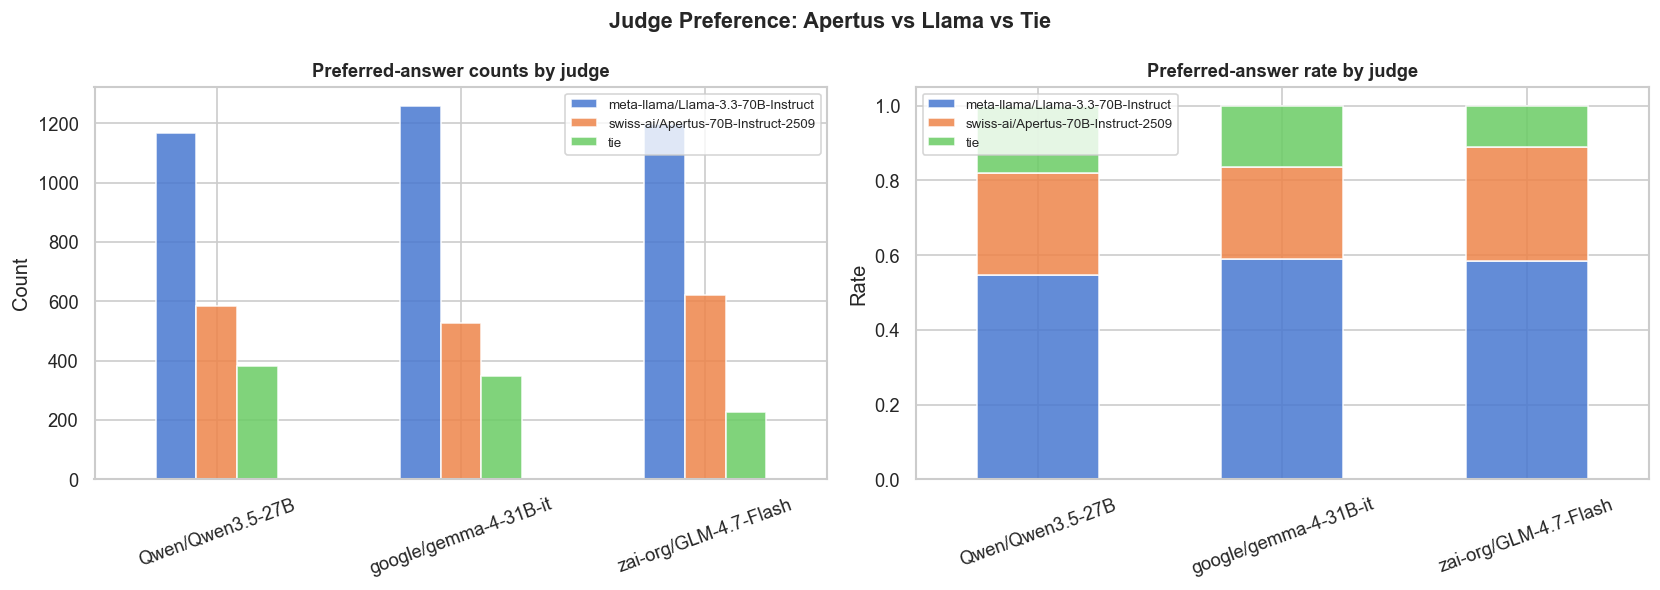

preferred,meta-llama/Llama-3.3-70B-Instruct,swiss-ai/Apertus-70B-Instruct-2509,tie
judge_model,,,
Qwen/Qwen3.5-27B,0.547,0.274,0.179
google/gemma-4-31B-it,0.590,0.246,0.164
zai-org/GLM-4.7-Flash,0.585,0.304,0.111


In [3]:
win_counts = (
    df.groupby(["judge_model", "preferred"]).size().unstack(fill_value=0)
)
win_rates = win_counts.div(win_counts.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
win_counts.plot.bar(ax=axes[0], alpha=0.85)
axes[0].set_title("Preferred-answer counts by judge", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)

win_rates.plot.bar(ax=axes[1], alpha=0.85, stacked=True)
axes[1].set_title("Preferred-answer rate by judge", fontsize=11, fontweight="bold")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(fontsize=8)

plt.suptitle("Judge Preference: Apertus vs Llama vs Tie", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

win_rates.round(3)

## 3 · Score-gap Distribution

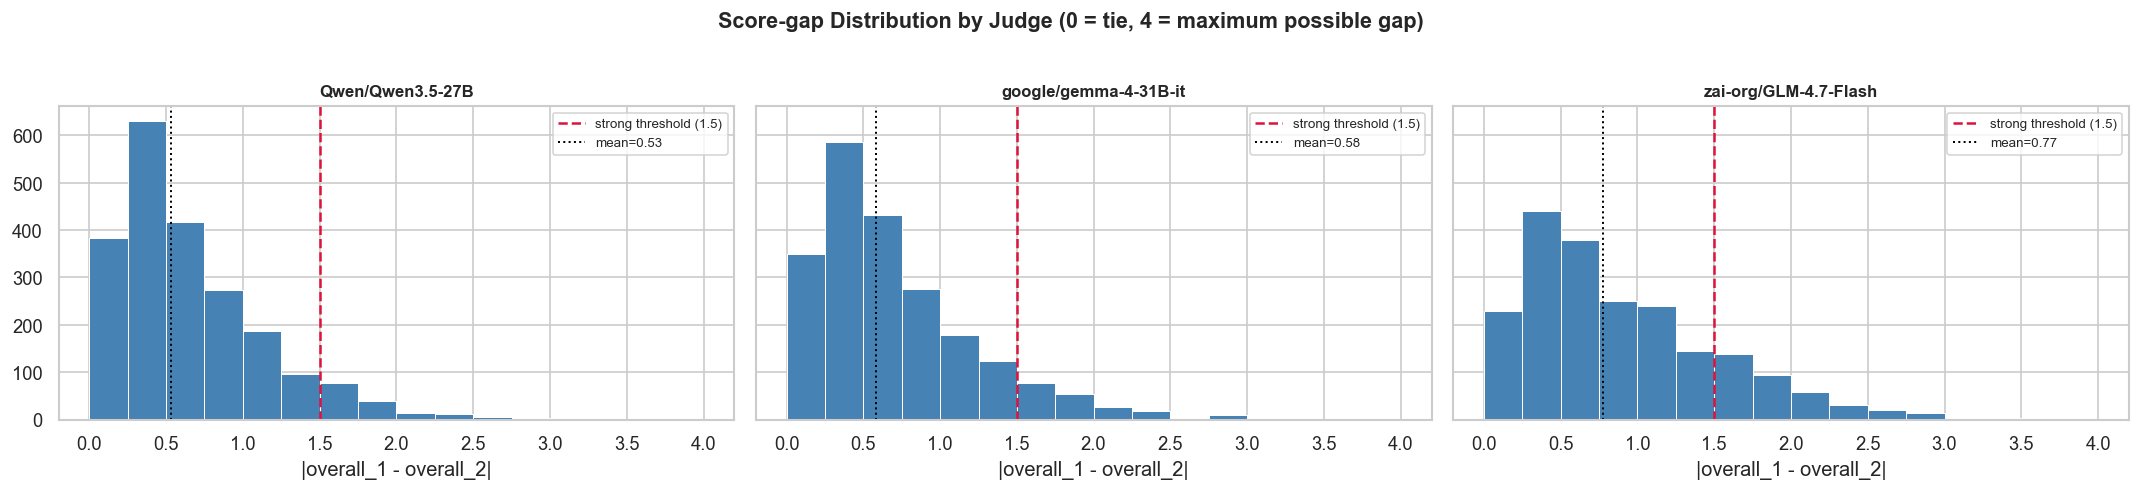

In [4]:
fig, axes = plt.subplots(1, len(JUDGES), figsize=(6 * len(JUDGES), 4), sharey=True)
bins = np.arange(0, 4.01, 0.25)

for ax, judge in zip(axes, JUDGES):
    data = df.loc[df["judge_model"] == judge, "abs_diff"]
    ax.hist(data, bins=bins, color="steelblue", edgecolor="white", linewidth=0.6)
    ax.axvline(STRONG_PREFERENCE_THRESHOLD, color="crimson", linestyle="--", linewidth=1.5,
               label=f"strong threshold ({STRONG_PREFERENCE_THRESHOLD})")
    ax.axvline(data.mean(), color="black", linestyle=":", linewidth=1.2, label=f"mean={data.mean():.2f}")
    ax.set_title(judge, fontsize=10, fontweight="bold")
    ax.set_xlabel("|overall_1 - overall_2|")
    ax.legend(fontsize=8)

plt.suptitle("Score-gap Distribution by Judge (0 = tie, 4 = maximum possible gap)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4 · Preference Strength Breakdown (tie / weak / strong)

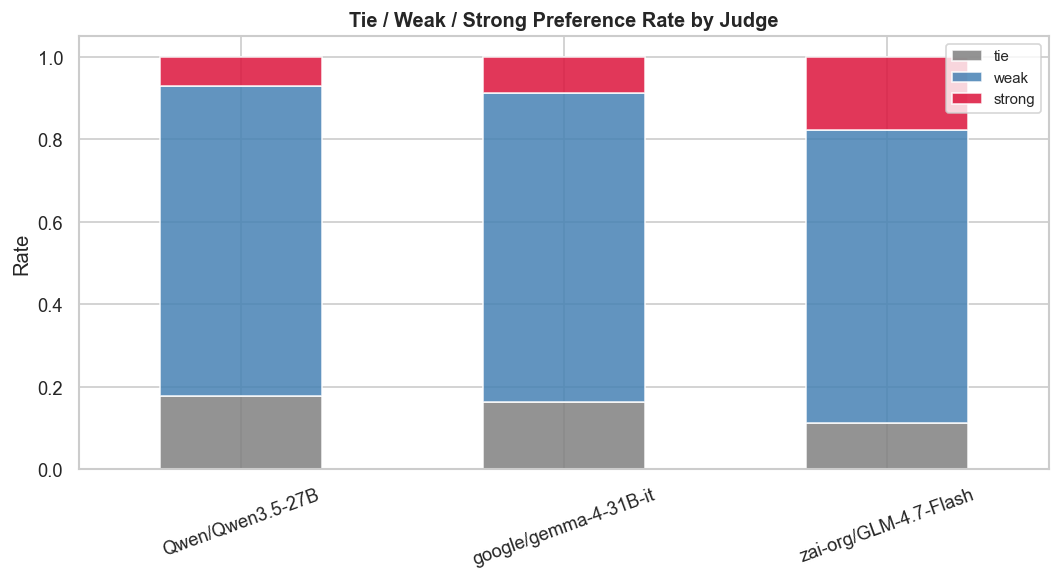

preference_strength,tie,weak,strong
judge_model,,,
Qwen/Qwen3.5-27B,382,1601,151
google/gemma-4-31B-it,349,1597,188
zai-org/GLM-4.7-Flash,228,1454,364


In [5]:
strength_counts = (
    df.groupby(["judge_model", "preference_strength"]).size().unstack(fill_value=0)
)
strength_counts = strength_counts[[c for c in ["tie", "weak", "strong"] if c in strength_counts.columns]]
strength_rates = strength_counts.div(strength_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
strength_rates.plot.bar(ax=ax, stacked=True, color=["grey", "steelblue", "crimson"], alpha=0.85)
ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.set_title("Tie / Weak / Strong Preference Rate by Judge", fontsize=12, fontweight="bold")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="", fontsize=9)
plt.tight_layout()
plt.show()

strength_counts

## 5 · By Regulator (EBA vs ESMA)

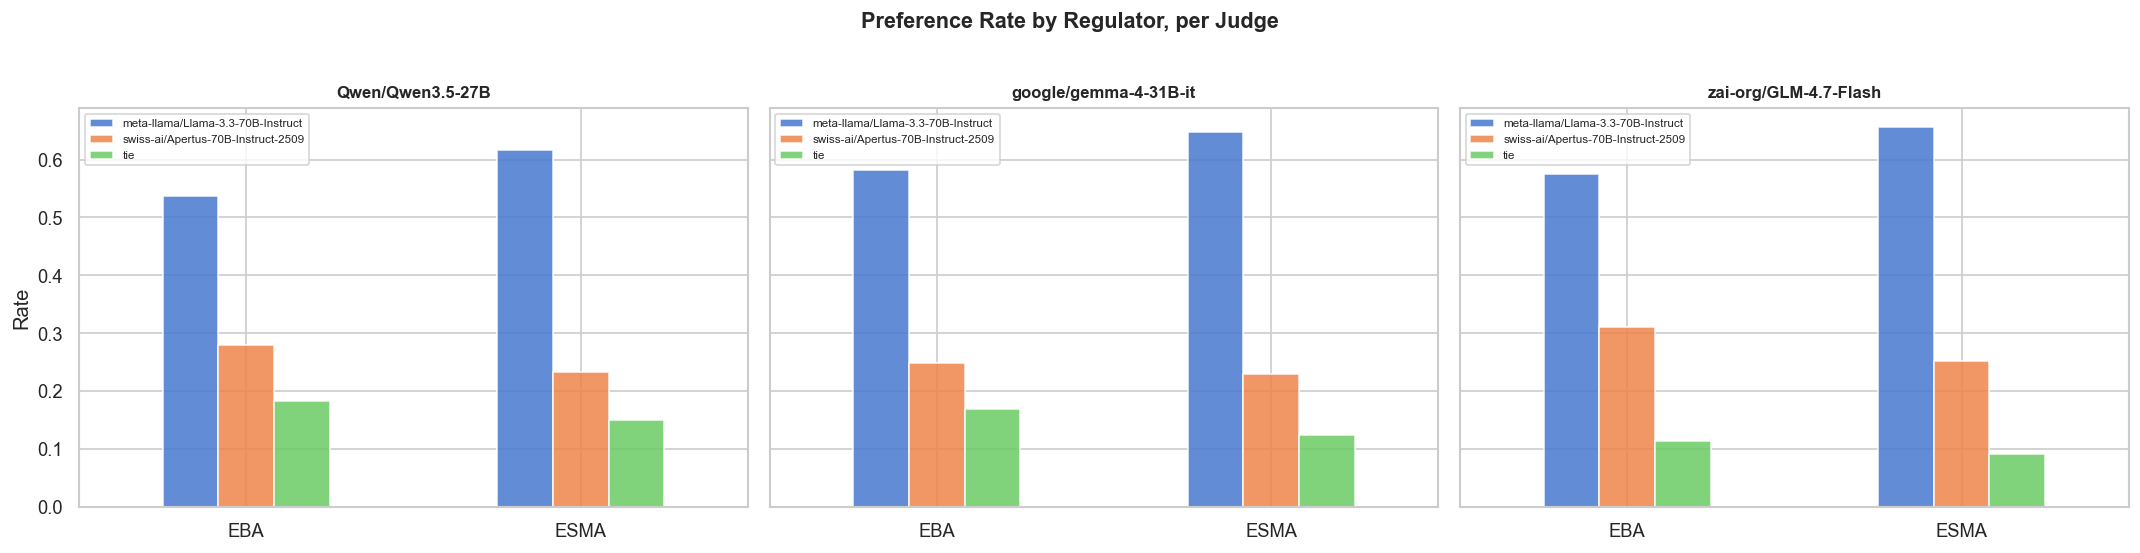

In [6]:
fig, axes = plt.subplots(1, len(JUDGES), figsize=(6 * len(JUDGES), 4.5), sharey=True)

for ax, judge in zip(axes, JUDGES):
    sub = df[df["judge_model"] == judge]
    rates = (
        sub.groupby(["regulator", "preferred"]).size().unstack(fill_value=0)
    )
    rates = rates.div(rates.sum(axis=1), axis=0)
    rates.plot.bar(ax=ax, alpha=0.85)
    ax.set_title(judge, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Rate")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=7)

plt.suptitle("Preference Rate by Regulator, per Judge", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 6 · Cross-judge Consensus

Questions                                : 2134
Unanimous (all 3 judges agree)            : 913 (42.8%)
Unanimous AND all strong preferences      : 52 (2.4%)

Majority-preferred distribution (ties counted as their own category):
majority_preferred
meta-llama/Llama-3.3-70B-Instruct     1283
swiss-ai/Apertus-70B-Instruct-2509     578
tie                                    273
Name: count, dtype: int64

Majority-vote count distribution (3 = unanimous, 2 = 2-1 split, 1 = fully split):
majority_count
1     244
2    1032
3     858
Name: count, dtype: int64


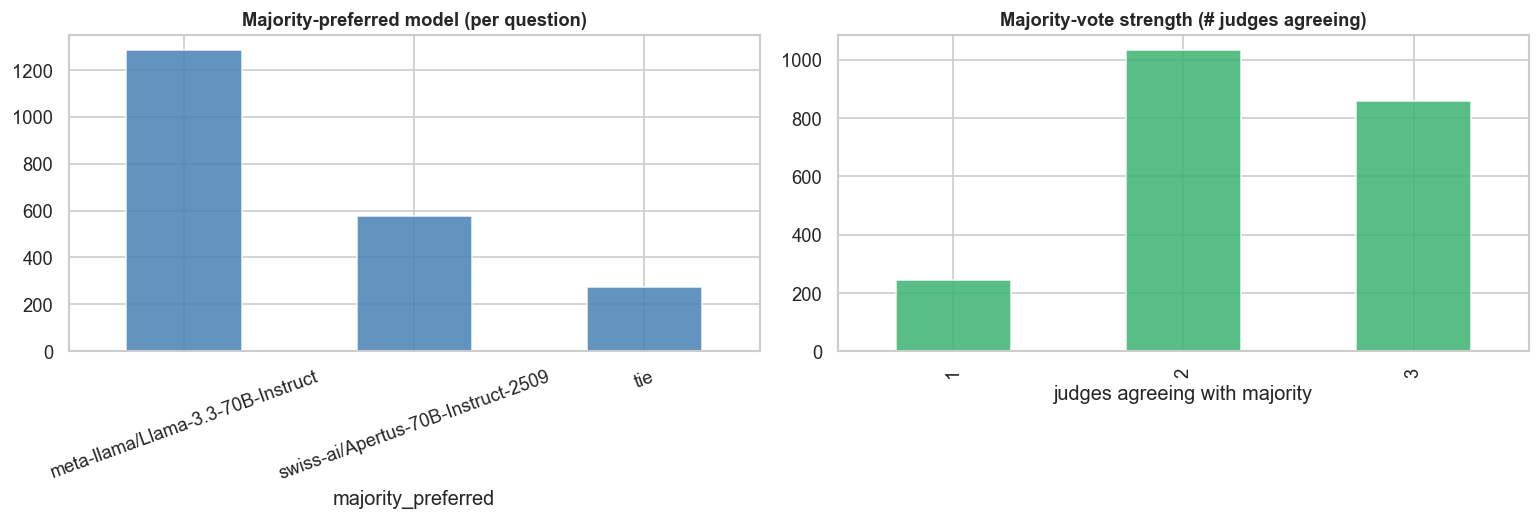

In [7]:
n = len(cdf)
n_unanimous = cdf["unanimous"].sum()
n_unanimous_strong = cdf["unanimous_strong"].sum()

print(f"Questions                                : {n}")
print(f"Unanimous (all 3 judges agree)            : {n_unanimous} ({n_unanimous/n*100:.1f}%)")
print(f"Unanimous AND all strong preferences      : {n_unanimous_strong} ({n_unanimous_strong/n*100:.1f}%)")
print()
print("Majority-preferred distribution (ties counted as their own category):")
print(cdf["majority_preferred"].value_counts())
print()
print("Majority-vote count distribution (3 = unanimous, 2 = 2-1 split, 1 = fully split):")
print(cdf["majority_count"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cdf["majority_preferred"].value_counts().plot.bar(ax=axes[0], color="steelblue", alpha=0.85)
axes[0].set_title("Majority-preferred model (per question)", fontsize=11, fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)

cdf["majority_count"].value_counts().sort_index().plot.bar(ax=axes[1], color="mediumseagreen", alpha=0.85)
axes[1].set_title("Majority-vote strength (# judges agreeing)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("judges agreeing with majority")

plt.tight_layout()
plt.show()

## 7 · Examples: Strongest Preferences (biggest score gaps)

In [8]:
# Load original records to pull question / answer text for the examples below
records = {}
with open(BASE / "judge_results_train_api.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            rec = json.loads(line)
            records[rec["question_id"]] = rec


def show_comparison(row, max_len=300):
    rec = records[row["question_id"]]
    a1, a2 = row["answerer_1"], row["answerer_2"]
    ans1 = rec["answers"][a1]["text"]
    ans2 = rec["answers"][a2]["text"]
    reasoning = rec["answers"][a1]["judge_scores"][row["judge_model"]].get("reasoning", {})

    print(f"\n{'='*90}")
    print(f"  [{row['question_id']}]  judge={row['judge_model']}  gap={row['abs_diff']:.2f}  "
          f"preferred={row['preferred']}")
    print(f"{'='*90}")
    print(f"QUESTION     : {rec['question'][:max_len]}")
    print(f"GROUND TRUTH : {rec['ground_truth'][:max_len]}")
    print(f"\n[{a1}]  overall={row['overall_1']}")
    print(f"  {ans1[:max_len]}")
    print(f"\n[{a2}]  overall={row['overall_2']}")
    print(f"  {ans2[:max_len]}")


top_gaps = df.nlargest(3, "abs_diff")
for _, row in top_gaps.iterrows():
    show_comparison(row)


  [EBA_2016_2660]  judge=zai-org/GLM-4.7-Flash  gap=3.50  preferred=meta-llama/Llama-3.3-70B-Instruct
QUESTION     : (a) Can the national competent authority of a Member State grant such exemption where the inflow arises from the parent companies or subsidiaries incorporated in third countries?
(b) If the reply to the first question is positive, shall the national competent authority carry out an assessment as req
GROUND TRUTH : According to Article 33(2)(a) of the Delegated Regulation (EU) 2015/61 subject to prior approval of the competent authority a credit institution may be fully or partially exempted from the cap on inflows (75% of outflows) where the provider is an intragroup entity irrespective of the country of resi

[meta-llama/Llama-3.3-70B-Instruct]  overall=5.0
  According to [Commission Delegated Regulation (EU) 2015/61, Art. 33(2)(a)], a credit institution may be exempted from the cap on inflows where the provider is a parent or a subsidiary within the same group, subjec

## 8 · Examples: Judge Disagreement (split decisions)

Questions where the 3 judges did **not** reach a majority of all 3 (i.e. a 2-1 split or a
fully 1-1-1 split) — these are cases where the pointwise scores genuinely disagree about
which answer is better.

In [9]:
split_decisions = cdf[~cdf["unanimous"]].copy()
print(f"Split-decision questions: {len(split_decisions)} / {len(cdf)} "
      f"({len(split_decisions)/len(cdf)*100:.1f}%)")

# Pick a few fully-split (1-1-1, i.e. majority_count == 1) examples if any exist,
# otherwise fall back to 2-1 splits.
fully_split = split_decisions[split_decisions["majority_count"] == 1]
sample_qids = (fully_split if len(fully_split) else split_decisions).sample(
    min(3, len(split_decisions)), random_state=42
)["question_id"]

for qid in sample_qids:
    rows = df[df["question_id"] == qid]
    rec = records[qid]
    print(f"\n{'='*90}")
    print(f"  [{qid}]")
    print(f"{'='*90}")
    print(f"QUESTION: {rec['question'][:300]}")
    for _, row in rows.iterrows():
        print(f"  judge={row['judge_model']:25s}  preferred={row['preferred']:45s}  "
              f"strength={row['preference_strength']:6s}  gap={row['abs_diff']:.2f}")

Split-decision questions: 1221 / 2134 (57.2%)

  [EBA_2013_576]
QUESTION: How should an institution that uses the standardized approach (for the purpose of calculating the capital requirement for credit risk) determine the exposure value of repurchase transactions with other banks if the collateral provided to the institution doesn’t qualify as eligible according to Artic
  judge=Qwen/Qwen3.5-27B           preferred=tie                                            strength=tie     gap=0.00
  judge=google/gemma-4-31B-it      preferred=meta-llama/Llama-3.3-70B-Instruct              strength=weak    gap=0.25
  judge=zai-org/GLM-4.7-Flash      preferred=swiss-ai/Apertus-70B-Instruct-2509             strength=weak    gap=0.75

  [EBA_2013_204]
QUESTION: It is unlcear from the instructions for the COREP which securtisations exposures should be filled in, in which tab (crsecirb, crsecsa and secdetails).
  judge=Qwen/Qwen3.5-27B           preferred=meta-llama/Llama-3.3-70B-Instruct              